In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import *
from sklearn.metrics import *
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("California_Houses.csv")
df

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,78100.0,1.5603,25,1665,374,845,330,39.48,-121.09,162031.481121,654530.186299,830631.543047,248510.058162,222619.890417
20636,77100.0,2.5568,18,697,150,356,114,39.49,-121.21,160445.433537,659747.068444,836245.915229,246849.888948,218314.424634
20637,92300.0,1.7000,17,2254,485,1007,433,39.43,-121.22,153754.341182,654042.214020,830699.573163,240172.220489,212097.936232
20638,84700.0,1.8672,18,1860,409,741,349,39.43,-121.32,152005.022239,657698.007703,834672.461887,238193.865909,207923.199166


In [7]:
# Y = df[['Median_House_Value']]
# Y

,Median_House_Value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0
...,...
20635,78100.0
20636,77100.0
20637,92300.0
20638,84700.0


In [8]:
y=df.iloc[:,0]
X=df.iloc[:,1:14]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100, shuffle = True)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.5, random_state = 100, shuffle = True)

In [11]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_val=scaler.transform(X_val)

ridge regression model using alpha=1.0

In [14]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

In [16]:
y_preds_val=ridge.predict(X_val)

In [21]:
mse_val=mean_squared_error(y_val,y_preds_val)
mse_scores={ridge:mse_val}
mae_val=mean_absolute_error(y_val,y_preds_val)
mae_scores={ridge:mae_val}

In [28]:
print(f"Mean Squared Error : {mse_val}")
print(f"Mean Absolute Error : {mae_val}")

Mean Squared Error for training data : 4538962578.863141
Mean Absolute Error for training data: 49631.15584889957


**ridge regression model using alpha=10**

In [32]:
ridge_1 = Ridge(alpha=10)
ridge_1.fit(X_train, y_train)

Ridge(alpha=10)

In [33]:
y_preds_val=ridge_1.predict(X_val)

In [35]:
mse_val=mean_squared_error(y_val,y_preds_val)
mse_scores[ridge_1]=mse_val
mae_val=mean_absolute_error(y_val,y_preds_val)
mae_scores[ridge_1]=mae_val

In [36]:
print(f"Mean Squared Error: {mse_val}")
print(f"Mean Absolute Error: {mae_val}")

Mean Squared Error for training data : 4547355593.219379
Mean Absolute Error for training data: 49719.09549080717


**ridge regression model using alpha=100**

In [37]:
ridge_2 = Ridge(alpha=100)
ridge_2.fit(X_train, y_train)

Ridge(alpha=100)

In [38]:
y_preds_val=ridge_2.predict(X_val)

In [52]:
mse_val=mean_squared_error(y_val,y_preds_val)
mse_scores[ridge_2]=mse_val
mae_val=mean_absolute_error(y_val,y_preds_val)
mae_scores[ridge_2]=mae_val

In [53]:
print(f"Mean Squared Error: {mse_val}")
print(f"Mean Absolute Error: {mae_val}")

Mean Squared Error for training data : 4812798048.653833
Mean Absolute Error for training data: 51572.084974272395


**ridge regression model using alpha=1000**

In [43]:
ridge_3 = Ridge(alpha=1000)
ridge_3.fit(X_train, y_train)

Ridge(alpha=1000)

In [44]:
y_preds_val=ridge_3.predict(X_val)

In [50]:
mse_val=mean_squared_error(y_val,y_preds_val)
mse_scores[ridge_3]=mse_val
mae_val=mean_absolute_error(y_val,y_preds_val)
mae_scores[ridge_3]=mae_val

In [46]:
print(f"Mean Squared Error: {mse_val}")
print(f"Mean Absolute Error: {mae_val}")

Mean Squared Error for training data : 4812798048.653833
Mean Absolute Error for training data: 51572.084974272395


In [51]:
mse_scores

{Ridge(alpha=1000): 4812798048.653833, Ridge(alpha=1000): 4812798048.653833}

In [60]:
best_fit_model=min(mse_scores, key=mse_scores.get)
y_preds=best_fit_model.predict(X_test)
mse=mean_squared_error(y_preds,y_test)
mae=mean_absolute_error(y_preds,y_test)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 4619351913.346923
Mean Absolute Error: 50940.649365087294


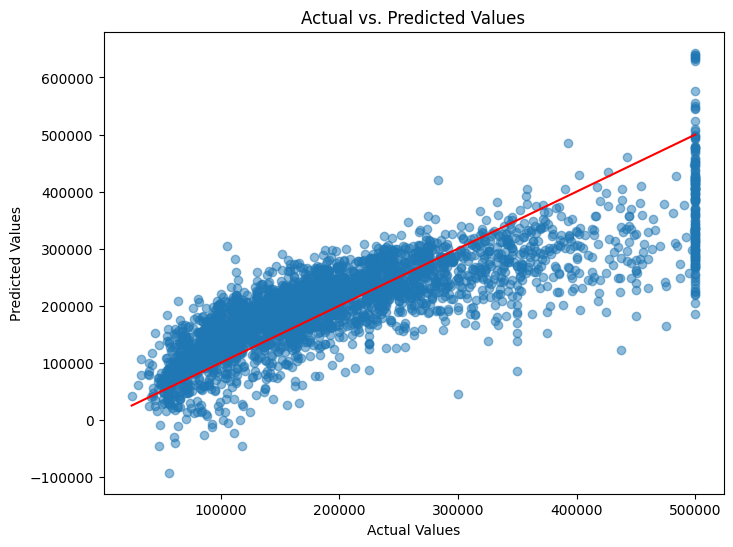

In [66]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='solid')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()